# Chapter 3 - Deep Q-learning
### Deep Reinforcement Learning *in Action*

##### Listing 3.1

In [1]:
!git clone https://github.com/DeepReinforcementLearning/DeepReinforcementLearningInAction.git
import os
os.chdir('DeepReinforcementLearningInAction/Chapter 3')
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Cloning into 'DeepReinforcementLearningInAction'...
remote: Enumerating objects: 264, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 264 (delta 12), reused 7 (delta 7), pack-reused 244 (from 3)
Receiving objects: 100% (264/264), 3.71 MiB | 17.67 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Using device: cuda


In [2]:
from Gridworld import Gridworld
game = Gridworld(size=4, mode='static')

In [3]:
game.display()

array([['+', '-', ' ', 'P'],
       [' ', 'W', ' ', ' '],
       [' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ']], dtype='<U2')

In [4]:
game.makeMove('d')
game.makeMove('d')
game.makeMove('l')
game.display()

array([['+', '-', ' ', ' '],
       [' ', 'W', ' ', ' '],
       [' ', ' ', 'P', ' '],
       [' ', ' ', ' ', ' ']], dtype='<U2')

In [5]:
game.reward()

-1

In [6]:
game.board.render_np()

array([[[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 0]],

       [[1, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]]], dtype=uint8)

In [7]:
action_set = {
    0: 'u',
    1: 'd',
    2: 'l',
    3: 'r',
}

###### Rainbow DQN

In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from Gridworld import Gridworld
from IPython.display import clear_output
import random
from matplotlib import pylab as plt
import copy
from collections import deque
import math

# ==========================================
# [新增] 1. Noisy Linear Layer (取代標準 nn.Linear)
# ==========================================
class NoisyLinear(nn.Module):
    def __init__(self, in_features, out_features, std_init=0.5):
        super(NoisyLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.std_init = std_init
        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        self.weight_sigma = nn.Parameter(torch.empty(out_features, in_features))
        self.register_buffer('weight_epsilon', torch.empty(out_features, in_features))
        self.bias_mu = nn.Parameter(torch.empty(out_features))
        self.bias_sigma = nn.Parameter(torch.empty(out_features))
        self.register_buffer('bias_epsilon', torch.empty(out_features))
        self.reset_parameters()
        self.reset_noise()

    def reset_parameters(self):
        mu_range = 1 / math.sqrt(self.in_features)
        self.weight_mu.data.uniform_(-mu_range, mu_range)
        self.weight_sigma.data.fill_(self.std_init / math.sqrt(self.in_features))
        self.bias_mu.data.uniform_(-mu_range, mu_range)
        self.bias_sigma.data.fill_(self.std_init / math.sqrt(self.out_features))

    def _scale_noise(self, size):
        x = torch.randn(size)
        return x.sign().mul_(x.abs().sqrt_())

    def reset_noise(self):
        epsilon_in = self._scale_noise(self.in_features)
        epsilon_out = self._scale_noise(self.out_features)
        self.weight_epsilon.copy_(torch.outer(epsilon_out, epsilon_in))
        self.bias_epsilon.copy_(epsilon_out)

    def forward(self, x):
        if self.training:
            weight = self.weight_mu + self.weight_sigma * self.weight_epsilon
            bias = self.bias_mu + self.bias_sigma * self.bias_epsilon
        else:
            weight = self.weight_mu
            bias = self.bias_mu
        return F.linear(x, weight, bias)

# ==========================================
# [修改] 2. Dueling Network 架構 (結合 Noisy Nets)
# ==========================================
class RainbowDQN(nn.Module):
    def __init__(self, num_inputs=64, num_actions=4):
        super(RainbowDQN, self).__init__()
        self.feature = nn.Sequential(
            nn.Linear(num_inputs, 150),
            nn.ReLU()
        )
        # 價值流 (Value Stream)
        self.value_stream = nn.Sequential(
            NoisyLinear(150, 100),
            nn.ReLU(),
            NoisyLinear(100, 1)
        )
        # 優勢流 (Advantage Stream)
        self.advantage_stream = nn.Sequential(
            NoisyLinear(150, 100),
            nn.ReLU(),
            NoisyLinear(100, num_actions)
        )

    def forward(self, x):
        features = self.feature(x)
        values = self.value_stream(features)
        advantages = self.advantage_stream(features)
        # Dueling 聚合公式: Q(s,a) = V(s) + (A(s,a) - mean(A))
        qvals = values + (advantages - advantages.mean(dim=1, keepdim=True))
        return qvals

    def reset_noise(self):
        for m in self.modules():
            if isinstance(m, NoisyLinear):
                m.reset_noise()

# ==========================================
# [新增] 3. Prioritized Experience Replay (PER) & N-step
# ==========================================
class PrioritizedNStepBuffer:
    def __init__(self, maxlen, n_step=3, gamma=0.9, alpha=0.6):
        self.buffer = deque(maxlen=maxlen)
        self.priorities = deque(maxlen=maxlen)
        self.n_step_buffer = deque(maxlen=n_step)
        self.n_step = n_step
        self.gamma = gamma
        self.alpha = alpha

    def append(self, state, action, reward, next_state, done):
        self.n_step_buffer.append((state, action, reward, next_state, done))
        if len(self.n_step_buffer) == self.n_step:
            r, s_next, d = self._get_n_step_info()
            s, a = self.n_step_buffer[0][0], self.n_step_buffer[0][1]
            max_p = max(self.priorities) if self.buffer else 1.0
            self.buffer.append((s, a, r, s_next, d))
            self.priorities.append(max_p)

    def _get_n_step_info(self):
        reward, next_state, done = self.n_step_buffer[-1][2], self.n_step_buffer[-1][3], self.n_step_buffer[-1][4]
        for transition in reversed(list(self.n_step_buffer)[:-1]):
            r, s_next, d = transition[2], transition[3], transition[4]
            reward = r + self.gamma * reward * (1 - d)
            if d: next_state, done = s_next, d
        return reward, next_state, done

    def sample(self, batch_size, beta=0.4):
        probs = np.array(self.priorities) ** self.alpha
        probs /= probs.sum()
        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        samples = [self.buffer[idx] for idx in indices]

        # 計算 Importance Sampling (IS) 權重
        total = len(self.buffer)
        weights = (total * probs[indices]) ** (-beta)
        weights /= weights.max()
        return samples, indices, torch.FloatTensor(weights).to(device)

    def update_priorities(self, indices, td_errors, offset=1e-5):
        for idx, err in zip(indices, td_errors):
            self.priorities[idx] = abs(err) + offset

    def __len__(self):
        return len(self.buffer)

# 初始化新模型
model = RainbowDQN().to(device)
model2 = copy.deepcopy(model).to(device)
model2.load_state_dict(model.state_dict())

# [修改] 移除了 epsilon，因為 Noisy Nets 已涵蓋探索機制
gamma = 0.9
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [9]:
epochs = 5000
losses = []
mem_size = 1000
batch_size = 200
n_step = 3 # [新增] N-step 步數設定

# [修改] 使用自建的 PER & N-step Buffer
replay = PrioritizedNStepBuffer(maxlen=mem_size, n_step=n_step, gamma=gamma)
max_moves = 50
sync_freq = 1000
j = 0

for i in range(epochs):
    # [修改] 將環境模式改為 'random'
    game = Gridworld(size=4, mode='random')
    state1_ = game.board.render_np().reshape(1,64) + np.random.rand(1,64)/100.0
    state1 = torch.from_numpy(state1_).float().to(device)
    status = 1
    mov = 0

    while(status == 1):
        j += 1
        mov += 1

        # [修改] Noisy Nets 取代了 epsilon-greedy 條件判斷，直接取 argmax
        with torch.no_grad():
            qval = model(state1)
        action_ = torch.argmax(qval).item()
        action = action_set[action_]

        game.makeMove(action)
        state2_ = game.board.render_np().reshape(1,64) + np.random.rand(1,64)/100.0
        state2 = torch.from_numpy(state2_).float().to(device)
        reward = game.reward()
        done = True if reward > 0 else False

        # [修改] 寫入 Buffer，內部會自動處理 N-step 延遲寫入與 Priority 給定
        replay.append(state1, action_, reward, state2, done)
        state1 = state2

        if len(replay) > batch_size:
            # [修改] 從 PER 中取樣，並獲取 IS weights 與 indices
            minibatch, indices, weights = replay.sample(batch_size)

            state1_batch = torch.cat([s1 for (s1,a,r,s2,d) in minibatch]).to(device)
            action_batch = torch.Tensor([a for (s1,a,r,s2,d) in minibatch]).to(device)
            reward_batch = torch.Tensor([r for (s1,a,r,s2,d) in minibatch]).to(device)
            state2_batch = torch.cat([s2 for (s1,a,r,s2,d) in minibatch]).to(device)
            done_batch = torch.Tensor([d for (s1,a,r,s2,d) in minibatch]).to(device)

            Q1 = model(state1_batch)
            with torch.no_grad():
                Q2_main = model(state2_batch)
                action_next = torch.argmax(Q2_main, dim=1)
                Q2_target = model2(state2_batch)

            Q2_val = Q2_target.gather(dim=1, index=action_next.unsqueeze(dim=1)).squeeze()

            # [修改] 計算目標值時，gamma 必須加上 N-step 的次方 (gamma ** n_step)
            Y = reward_batch + (gamma ** n_step) * ((1-done_batch) * Q2_val)
            X = Q1.gather(dim=1, index=action_batch.long().unsqueeze(dim=1)).squeeze()

            # [修改] 結合 PER 權重計算 Loss
            td_errors = Y.detach() - X
            loss = (weights * (td_errors ** 2)).mean()

            # [新增] 根據計算出的 TD-Error 更新 Buffer 內的優先級
            replay.update_priorities(indices, td_errors.detach().cpu().numpy())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # [新增] 每次反向傳播後，重置 Noisy Network 的隨機噪聲
            model.reset_noise()
            model2.reset_noise()

            print(i, loss.item())
            clear_output(wait=True)
            losses.append(loss.item())

            if j % sync_freq == 0:
                model2.load_state_dict(model.state_dict())

        if reward != -1 or mov > max_moves:
            status = 0
            mov = 0

4999 1.0382251739501953


Text(0, 0.5, 'Loss')

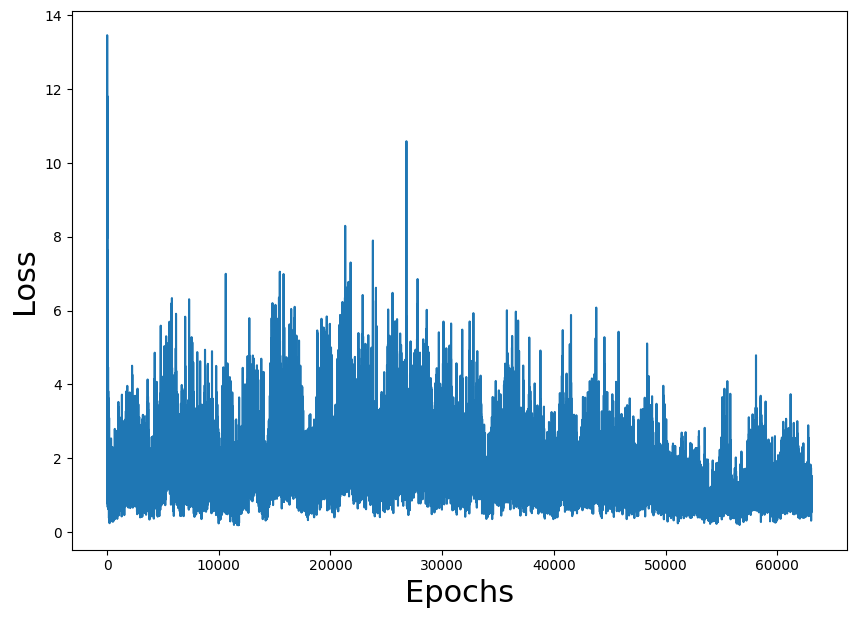

In [10]:
plt.figure(figsize=(10,7))
plt.plot(losses)
plt.xlabel("Epochs",fontsize=22)
plt.ylabel("Loss",fontsize=22)

In [11]:
def test_model(model, mode='static', display=True):
    i = 0
    test_game = Gridworld(mode=mode)
    state_ = test_game.board.render_np().reshape(1,64) + np.random.rand(1,64)/10.0
    state = torch.from_numpy(state_).float().to(device)
    if display:
        print("Initial State:")
        print(test_game.display())
    status = 1
    while(status == 1): #A
        qval = model(state)
        qval_ = qval.cpu().data.numpy()
        action_ = np.argmax(qval_) #B
        action = action_set[action_]
        if display:
            print('Move #: %s; Taking action: %s' % (i, action))
        test_game.makeMove(action)
        state_ = test_game.board.render_np().reshape(1,64) + np.random.rand(1,64)/10.0
        state = torch.from_numpy(state_).float().to(device)
        if display:
            print(test_game.display())
        reward = test_game.reward()
        if reward != -1:
            if reward > 0:
                status = 2
                if display:
                    print("Game won! Reward: %s" % (reward,))
            else:
                status = 0
                if display:
                    print("Game LOST. Reward: %s" % (reward,))
        i += 1
        if (i > 15):
            if display:
                print("Game lost; too many moves.")
            break

    win = True if status == 2 else False
    return win

In [12]:
max_games = 1000
wins = 0
for i in range(max_games):
    win = test_model(model, mode='player', display=False)
    if win:
        wins += 1
win_perc = float(wins) / float(max_games)
print("Games played: {0}, # of wins: {1}".format(max_games,wins))
print("Win percentage: {}%".format(100.0*win_perc))

Games played: 1000, # of wins: 957
Win percentage: 95.7%
